SARIMA Example build for Analysis Assessment Job

In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt 

In [19]:
data_location = '/Users/zacwells/Documents/Python-Projects/Job examples/sarima_volume_data.csv'

daily_volumes = pd.read_csv(data_location)
daily_volumes['date'] = pd.to_datetime(daily_volumes['date'])
daily_volumes['week_commencing'] = daily_volumes['date'] - pd.to_timedelta(daily_volumes['date'].dt.weekday, unit='d')
display(daily_volumes.head())
print(daily_volumes.dtypes)

,date,volume,week_commencing
0,2022-01-01,102.827602,2021-12-27
1,2022-01-02,100.075442,2021-12-27
2,2022-01-03,104.427734,2022-01-03
3,2022-01-04,109.226664,2022-01-03
4,2022-01-05,100.862564,2022-01-03


date               datetime64[ns]
volume                    float64
week_commencing    datetime64[ns]
dtype: object


In [20]:
weekly_volumes = daily_volumes.groupby('week_commencing').agg({'volume': 'sum'}).reset_index()
display(weekly_volumes.head())

,week_commencing,volume
0,2021-12-27,202.903044
1,2022-01-03,735.071941
2,2022-01-10,715.923561
3,2022-01-17,749.117345
4,2022-01-24,759.388002


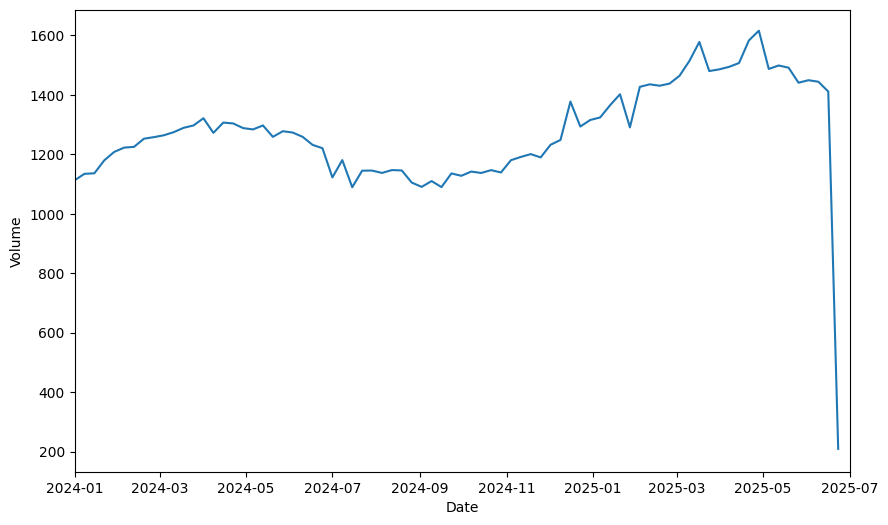

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(weekly_volumes['week_commencing'], weekly_volumes['volume'])
plt.xlabel('Date')
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-07-01'))
plt.ylabel('Volume')
plt.show()

In [70]:
data = '/Users/zacwells/Documents/Python-Projects/Job examples/sarima_volume_weekly.csv'

day = pd.read_csv(data)
day['date'] = pd.to_datetime(day['date'])
day['week_commencing'] = day['date'] - pd.to_timedelta(day['date'].dt.weekday, unit='d')

week = day.groupby('week_commencing').agg({'volume': 'sum'}).reset_index()

orders = [
    (2, 1, 2),
    (3, 1, 3),
    (4, 1, 4),
    (1, 1, 1),
]

seasonal_orders = [
    (1, 1, 1, 52),   # annual
    (2, 1, 1, 52),
    (2, 1, 2, 52),
    (1, 1, 1, 26),   # half-year
    (1, 1, 1, 13),    # quarterly
    (0, 1, 0, 13)    # quarterly
]

best_score = float('inf')
best_order = None
best_season = None
best_mse = None
best_r2 = None

for order in orders:
    for season in seasonal_orders:
        try:
            print(f"Testing SARIMA config: order={order}, seasonal_order={season}")

            model = SARIMAX(
                week['volume'],
                order=order,
                seasonal_order=season,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=True)

            predictions = model.predict(start=52, end=len(week)-1)

            actual = week['volume'][52:]
            mse = np.mean((predictions - actual) ** 2)
            r2 = 1 - np.sum((predictions - actual) ** 2) / np.sum((actual - np.mean(actual)) ** 2)

            # Combine both into a custom score (lower is better)
            # Avoid division by zero or negative R²
            if r2 > 0:
                score = mse / r2
            else:
                score = float('inf')

            print(f"  MSE: {mse:.2f} | R²: {r2:.3f} | Combined Score: {score:.2f}")

            if score < best_score:
                best_score = score
                best_order = order
                best_season = season
                best_mse = mse
                best_r2 = r2

        except Exception as e:
            print(f"  Failed for config {order}-{season}: {e}")
            continue

print("\n🏆 Best Model:")
print(f"  Order: {best_order}")
print(f"  Seasonal Order: {best_season}")
print(f"  MSE: {best_mse:.2f}")
print(f"  R²: {best_r2:.3f}")


week['prediction'] = SARIMAX(
    week['volume'],
    order=best_order,
    seasonal_order=best_season,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False).predict(start=52, end=len(week)-1)
week['rolling_std'] = week['volume'].rolling(window=12).std()

display(week.head())


Testing SARIMA config: order=(2, 1, 2), seasonal_order=(1, 1, 1, 52)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


  MSE: 31818.45 | R²: 0.370 | Combined Score: 85896.74
Testing SARIMA config: order=(2, 1, 2), seasonal_order=(2, 1, 1, 52)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/

  MSE: 33836.45 | R²: 0.330 | Combined Score: 102380.27
Testing SARIMA config: order=(2, 1, 2), seasonal_order=(2, 1, 2, 52)


...

  MSE: 30040.69 | R²: 0.406 | Combined Score: 74064.40
Testing SARIMA config: order=(1, 1, 1), seasonal_order=(1, 1, 1, 13)
  MSE: 29084.71 | R²: 0.425 | Combined Score: 68512.34
Testing SARIMA config: order=(1, 1, 1), seasonal_order=(0, 1, 0, 13)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


  MSE: 38299.01 | R²: 0.242 | Combined Score: 158129.78

🏆 Best Model:
  Order: (3, 1, 3)
  Seasonal Order: (1, 1, 1, 26)
  MSE: 26582.30
  R²: 0.474


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,week_commencing,volume,prediction,rolling_std
0,2021-12-27,204.695293,NaN,NaN
1,2022-01-03,752.969947,NaN,NaN
2,2022-01-10,694.198007,NaN,NaN
3,2022-01-17,740.559791,NaN,NaN
4,2022-01-24,741.758820,NaN,NaN


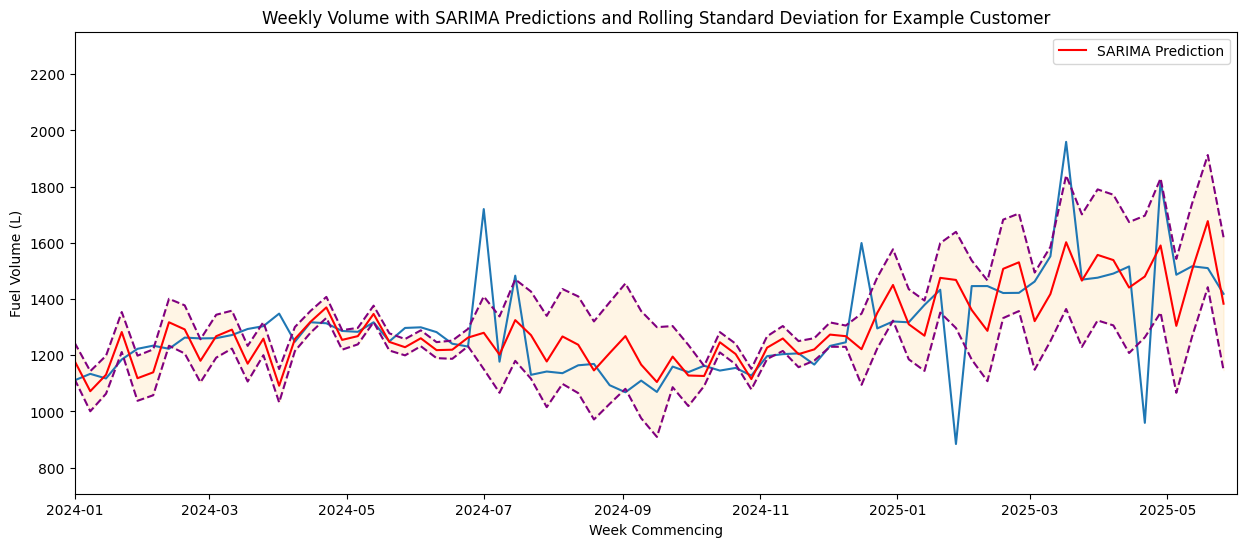

Mean Squared Error of the SARIMA model: 22110.69
R-squared of the SARIMA model: 0.32
Mean Squared Error of the Naive model: 100602.85
R-squared of the Naive model: -1.16
Mean Absolute Error of the SARIMA model: 95.74
Mean Absolute Percentage Error of the SARIMA model: 7.52%


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


BIC of the SARIMA model: 252.30


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [80]:
week = week[(week['week_commencing'] >= pd.to_datetime('2024-01-01')) &
            (week['week_commencing'] <= pd.to_datetime('2025-06-01'))]

plt.figure(figsize=(15, 6))
plt.plot(week['week_commencing'], week['volume'])
plt.plot(week['week_commencing'], week['prediction'], color='red', linestyle='-', label='SARIMA Prediction')
plt.plot(week['week_commencing'], week['prediction'] + week['rolling_std'], color='purple', linestyle='--')
plt.plot(week['week_commencing'], week['prediction'] - week['rolling_std'], color='purple', linestyle='--')
plt.fill_between(
    week['week_commencing'],
    week['prediction'] - week['rolling_std'],
    week['prediction'] + week['rolling_std'],
    color='orange',
    alpha=0.1
)
plt.legend()
plt.title('Weekly Volume with SARIMA Predictions and Rolling Standard Deviation for Example Customer')
plt.xlabel('Week Commencing')
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-06-01'))
plt.ylim(week['volume'].min()*0.8, week['volume'].max()*1.2)
plt.ylabel('Fuel Volume (L)')
plt.show()

mse = np.mean((week['prediction'] - week['volume']) ** 2)
print(f'Mean Squared Error of the SARIMA model: {mse:.2f}')
r2 = 1 - (np.sum((week['prediction'] - week['volume']) ** 2) / np.sum((week['volume'] - np.mean(week['volume'])) ** 2))
print(f'R-squared of the SARIMA model: {r2:.2f}')
naive_mse = np.mean((week['volume'][52:] - week['volume'].shift(1)[52:]) ** 2)
print(f'Mean Squared Error of the Naive model: {naive_mse:.2f}')
naive_r2 = 1 - (np.sum((week['volume'][52:] - week['volume'].shift(1)[52:]) ** 2) / np.sum((week['volume'][52:] - np.mean(week['volume'][52:])) ** 2))
print(f'R-squared of the Naive model: {naive_r2:.2f}')
mae = np.mean(np.abs(week['prediction'] - week['volume']))
print(f'Mean Absolute Error of the SARIMA model: {mae:.2f}')
mape = np.mean(np.abs((week['prediction'] - week['volume']) / week['volume'])) * 100
print(f'Mean Absolute Percentage Error of the SARIMA model: {mape:.2f}%')
bic = SARIMAX(
    week['volume'],
    order=best_order,
    seasonal_order=best_season,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False).bic
print(f'BIC of the SARIMA model: {bic:.2f}')

In [73]:
fitted_model = SARIMAX(
    week['volume'],
    order=best_order,
    seasonal_order=best_season,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
print(fitted_model.summary())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


                                      SARIMAX Results                                       
Dep. Variable:                               volume   No. Observations:                  183
Model:             SARIMAX(3, 1, 3)x(1, 1, [1], 26)   Log Likelihood                -818.609
Date:                              Mon, 23 Jun 2025   AIC                           1655.219
Time:                                      13:45:07   BIC                           1680.745
Sample:                                           0   HQIC                          1665.589
                                              - 183                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6182      0.164     -3.761      0.000      -0.940      -0.296
ar.L2         -0.76

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
